# Замер метрики IoU на реальных данных

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
import time
from scipy.linalg import svd
import pydicom
from pathlib import Path
from PIL import Image
import glob
from scipy.ndimage import gaussian_filter
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [2]:
!pip install pydicom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
def load_and_display_sample_case(base_path, case_id=None):
    """
    Загружает и отображает один срез из всех четырех модальностей одного случая.
    
    Args:
        base_path: Путь к директории с данными (train или validation)
        case_id: ID случая для загрузки (если None, будет выбран первый доступный)
        
    Returns:
        Словарь с загруженными данными
    """
    if case_id is None:
        case_dirs = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
        if not case_dirs:
            raise ValueError(f"Не найдено директорий с случаями в {base_path}")
        case_id = case_dirs[0]
    
    case_path = os.path.join(base_path, case_id)
    print(f"Загрузка случая {case_id} из {case_path}")
    
    modalities = ['FLAIR', 'T1w', 'T1wCE', 'T2w']
    
    case_data = {}
    
    # Загружаем каждую модальность
    for modality in modalities:
        modality_path = os.path.join(case_path, modality)
        
        if not os.path.exists(modality_path):
            print(f"Предупреждение: директория {modality_path} не найдена")
            continue
        
        # Получаем список всех DICOM файлов в директории
        dicom_files = sorted([f for f in os.listdir(modality_path) if f.endswith('.dcm')])
        
        if not dicom_files:
            print(f"Предупреждение: не найдено DICOM файлов в {modality_path}")
            continue
        
        # Загружаем средний срез для демонстрации
        middle_slice_idx = len(dicom_files) // 2
        middle_slice_path = os.path.join(modality_path, dicom_files[middle_slice_idx])
        
        try:
            dicom_data = pydicom.dcmread(middle_slice_path)
            pixel_array = dicom_data.pixel_array
            
            # Нормализуем для отображения
            if pixel_array.max() > 0:
                pixel_array = pixel_array / pixel_array.max()
            
            case_data[modality] = {
                'pixel_array': pixel_array,
                'dicom_data': dicom_data
            }
            
            print(f"Загружен срез {middle_slice_idx+1}/{len(dicom_files)} для модальности {modality}")
            print(f"Размер изображения: {pixel_array.shape}")
            
        except Exception as e:
            print(f"Ошибка при загрузке {middle_slice_path}: {e}")
    
    # Отображаем все модальности
    if case_data:
        plt.figure(figsize=(16, 4))
        
        for i, modality in enumerate(modalities):
            if modality in case_data:
                plt.subplot(1, 4, i+1)
                plt.imshow(case_data[modality]['pixel_array'], cmap='gray')
                plt.title(f"{modality}")
                plt.axis('off')
        
        plt.tight_layout()
        plt.suptitle(f"Случай {case_id} - Средние срезы", fontsize=16)
        plt.subplots_adjust(top=0.85)
        plt.savefig(f"case_{case_id}_sample.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Не удалось загрузить данные для отображения")
    
    return case_data

def read_labels(labels_path):
    """
    Считывает файл с метками MGMT_value.
    
    Args:
        labels_path: Путь к CSV файлу с метками
        
    Returns:
        Словарь {case_id: MGMT_value}
    """
    import pandas as pd
    labels_df = pd.read_csv(labels_path)
    labels = dict(zip(labels_df['BraTS21ID'].astype(str).str.zfill(5), labels_df['MGMT_value']))
    print(f"Загружено {len(labels)} меток")
    return labels


===== Загрузка снимка 1 =====
Загрузка случая 00000 из ./data/00000
Загружен срез 201/400 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 17/33 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 205/408 для модальности T2w
Размер изображения: (512, 512)


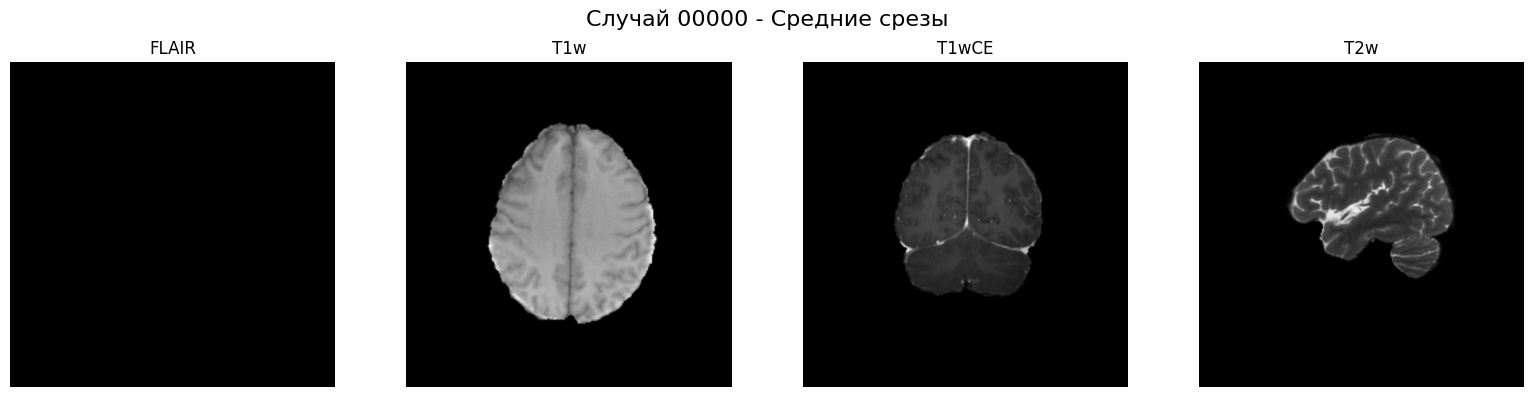

Загружено 585 меток
MGMT статус для случая 00000: 1

===== Загрузка снимка 2 =====
Загрузка случая 00002 из ./data/00002
Загружен срез 65/129 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 16/31 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 193/384 для модальности T2w
Размер изображения: (512, 512)


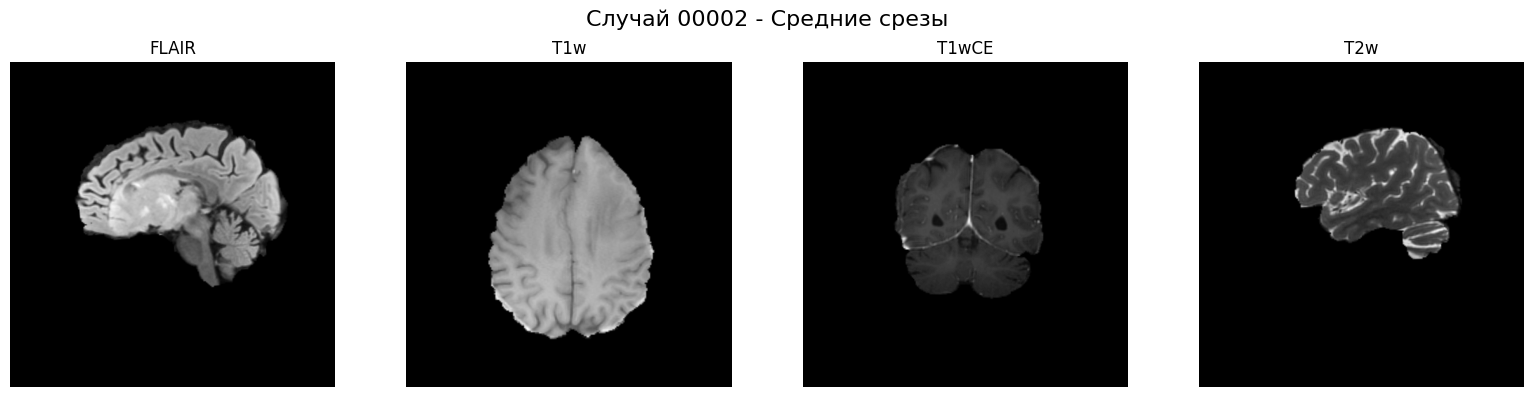

Загружено 585 меток
MGMT статус для случая 00002: 1

===== Загрузка снимка 3 =====
Загрузка случая 00003 из ./data/00003
Загружен срез 65/129 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 17/33 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 205/408 для модальности T2w
Размер изображения: (512, 512)


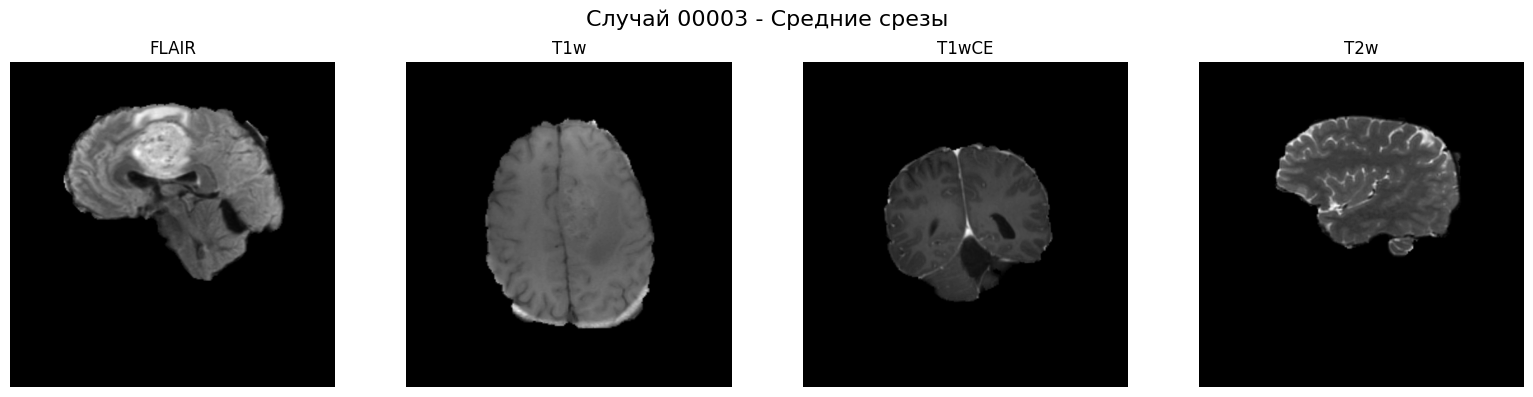

Загружено 585 меток
MGMT статус для случая 00003: 0


In [7]:
if __name__ == "__main__":
    base_path = "./data"
    
    for i in range(3):
        print(f"\n===== Загрузка снимка {i+1} =====")
        case_dirs = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
        
        if not case_dirs:
            print(f"Не найдено директорий с случаями в {base_path}")
            break
    
        case_id = case_dirs[i] if i < len(case_dirs) else case_dirs[0]
        case_data = load_and_display_sample_case(base_path, case_id)
        
        try:
            labels = read_labels("train_labels.csv")
            if case_id in labels:
                print(f"MGMT статус для случая {case_id}: {labels[case_id]}")
        except Exception as e:
            print(f"Не удалось загрузить метки: {e}")


# Маски сегментации

Найдено 51 файлов с опухолями и 51 файлов с масками
Первые 3 файлов опухолей: ['TCGA_CS_4941_19960909_11.tif', 'TCGA_CS_4941_19960909_14.tif', 'TCGA_CS_4943_20000902_13.tif']
Первые 3 файлов масок: ['TCGA_CS_4941_19960909_11_mask.tif', 'TCGA_CS_4941_19960909_14_mask.tif', 'TCGA_CS_4943_20000902_13_mask.tif']
Загружен снимок 1: TCGA_CS_4941_19960909_11.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)
Загружен снимок 2: TCGA_CS_4941_19960909_14.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)
Загружен снимок 3: TCGA_CS_4943_20000902_13.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)


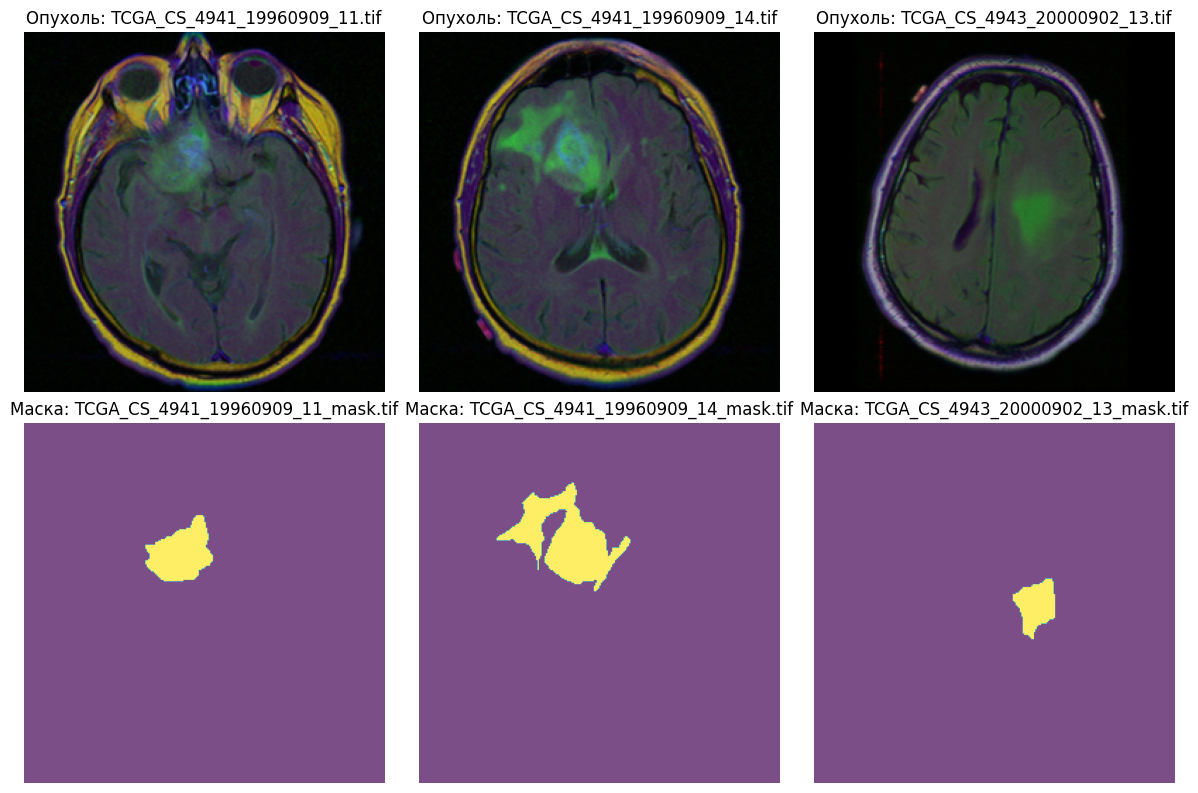

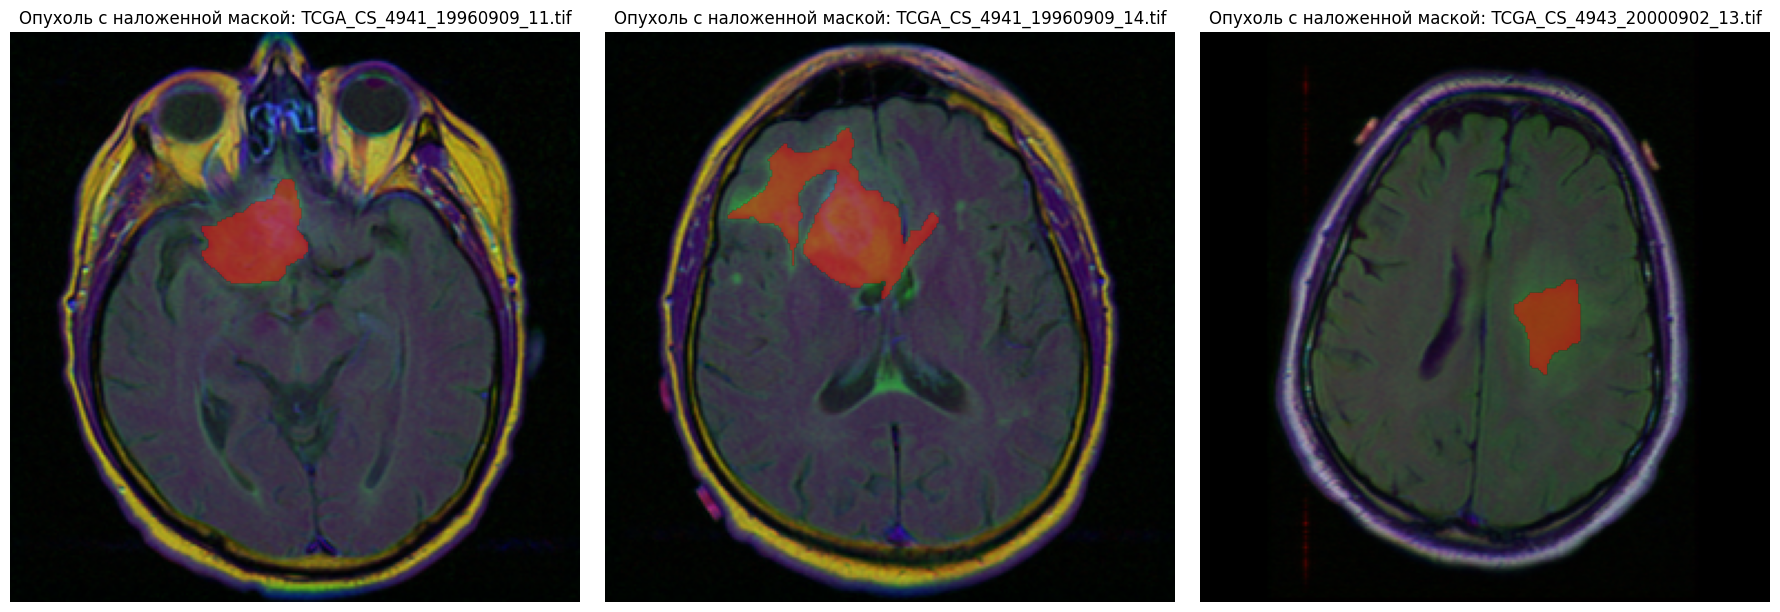

In [ ]:
def load_and_display_custom_dataset(base_path, num_samples=3):
    """
    Загружает и отображает пары снимков (опухоль и маска) из папок Tumor и Mask.
    
    Args:
        base_path: Путь к директории brain_tumor_custom
        num_samples: Количество пар снимков для отображения
    
    Returns:
        Словарь с загруженными изображениями
    """
    if not os.path.exists(base_path):
        raise ValueError(f"Директория {base_path} не существует")
    
    tumor_dir = os.path.join(base_path, "Tumor")
    mask_dir = os.path.join(base_path, "Mask")
    
    if not os.path.exists(tumor_dir) or not os.path.exists(mask_dir):
        raise ValueError(f"Директории Tumor или Mask не найдены в {base_path}")
    
    tumor_files = sorted(glob.glob(os.path.join(tumor_dir, "*.tif")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))
    
    if not tumor_files or not mask_files:
        raise ValueError(f"TIF файлы не найдены в директориях {tumor_dir} или {mask_dir}")
    
    print(f"Найдено {len(tumor_files)} файлов с опухолями и {len(mask_files)} файлов с масками")
    
    tumor_files = tumor_files[:num_samples]
    mask_files = mask_files[:num_samples]
    
    tumor_basenames = [os.path.basename(f) for f in tumor_files]
    mask_basenames = [os.path.basename(f) for f in mask_files]
    
    print(f"Первые {num_samples} файлов опухолей: {tumor_basenames}")
    print(f"Первые {num_samples} файлов масок: {mask_basenames}")
    
    loaded_images = {}
    
    for i, (tumor_file, mask_file) in enumerate(zip(tumor_files, mask_files)):
        try:
            tumor_image = np.array(Image.open(tumor_file))
            mask_image = np.array(Image.open(mask_file))
            
            tumor_basename = os.path.basename(tumor_file)
            mask_basename = os.path.basename(mask_file)
            
            print(f"Загружен снимок {i+1}: {tumor_basename}")
            print(f"Размер снимка опухоли: {tumor_image.shape}")
            print(f"Размер маски: {mask_image.shape}")
            
            loaded_images[i] = {
                'tumor': {
                    'image': tumor_image,
                    'filename': tumor_basename
                },
                'mask': {
                    'image': mask_image,
                    'filename': mask_basename
                }
            }
            
        except Exception as e:
            print(f"Ошибка при загрузке файлов {tumor_file} или {mask_file}: {e}")
    
    visualize_tumor_and_masks(loaded_images)
    
    return loaded_images

def visualize_tumor_and_masks(loaded_images):
    """
    Визуализирует пары снимков (опухоль и маска).
    
    Args:
        loaded_images: Словарь с загруженными изображениями
    """
    if not loaded_images:
        print("Нет данных для визуализации.")
        return
    
    n_samples = len(loaded_images)
    plt.figure(figsize=(4*n_samples, 8))
    
    for i, (idx, img_data) in enumerate(loaded_images.items()):
        tumor_image = img_data['tumor']['image']
        tumor_filename = img_data['tumor']['filename']
        
        mask_image = img_data['mask']['image']
        mask_filename = img_data['mask']['filename']
        
        plt.subplot(2, n_samples, i+1)
        
        # Проверяем, цветное ли изображение
        if len(tumor_image.shape) == 3 and tumor_image.shape[2] == 3:
            plt.imshow(tumor_image)
        else:
            plt.imshow(tumor_image, cmap='gray')
            
        plt.title(f"Опухоль: {tumor_filename}")
        plt.axis('off')
        plt.subplot(2, n_samples, i+1+n_samples)
        
        if mask_image.dtype == bool or np.array_equal(np.unique(mask_image), [0, 1]):
            plt.imshow(mask_image, cmap='binary', alpha=0.7)
        elif len(np.unique(mask_image)) <= 4:
            plt.imshow(mask_image, cmap='viridis', alpha=0.7)
        else:
            if len(mask_image.shape) == 3 and mask_image.shape[2] == 3:
                plt.imshow(mask_image)
            else:
                plt.imshow(mask_image, cmap='gray')
            
        plt.title(f"Маска: {mask_filename}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("tumor_and_masks.png", dpi=300, bbox_inches='tight')
    plt.show()

def visualize_overlay(loaded_images):
    """
    Визуализирует наложение маски на оригинальное изображение.
    
    Args:
        loaded_images: Словарь с загруженными изображениями
    """
    if not loaded_images:
        print("Нет данных для визуализации.")
        return
    
    n_samples = len(loaded_images)
    plt.figure(figsize=(6*n_samples, 6))
    
    for i, (idx, img_data) in enumerate(loaded_images.items()):
        tumor_image = img_data['tumor']['image']
        tumor_filename = img_data['tumor']['filename']
        
        mask_image = img_data['mask']['image']
        
        plt.subplot(1, n_samples, i+1)
        
        if len(tumor_image.shape) == 3 and tumor_image.shape[2] == 3:
            plt.imshow(tumor_image)
        else:
            plt.imshow(tumor_image, cmap='gray')
        
        if not np.array_equal(np.unique(mask_image), [0, 1]) and mask_image.dtype != bool:
            binary_mask = mask_image > 0
        else:
            binary_mask = mask_image.astype(bool)
        
        mask_overlay = np.zeros((*binary_mask.shape, 4))
        mask_overlay[binary_mask] = [1, 0, 0, 0.5]  # Красный цвет с прозрачностью
        
        plt.imshow(mask_overlay)
        plt.title(f"Опухоль с наложенной маской: {tumor_filename}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("tumor_mask_overlay.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    base_path = "brain_tumor_custom"
    
    try:
        loaded_images = load_and_display_custom_dataset(base_path, num_samples=3)
        visualize_overlay(loaded_images)
        
    except Exception as e:
        print(f"Произошла ошибка: {e}")


# Предсказание масок

Computing reconstruction errors: 100%|██████████| 7803/7803 [00:00<00:00, 65829.69it/s]


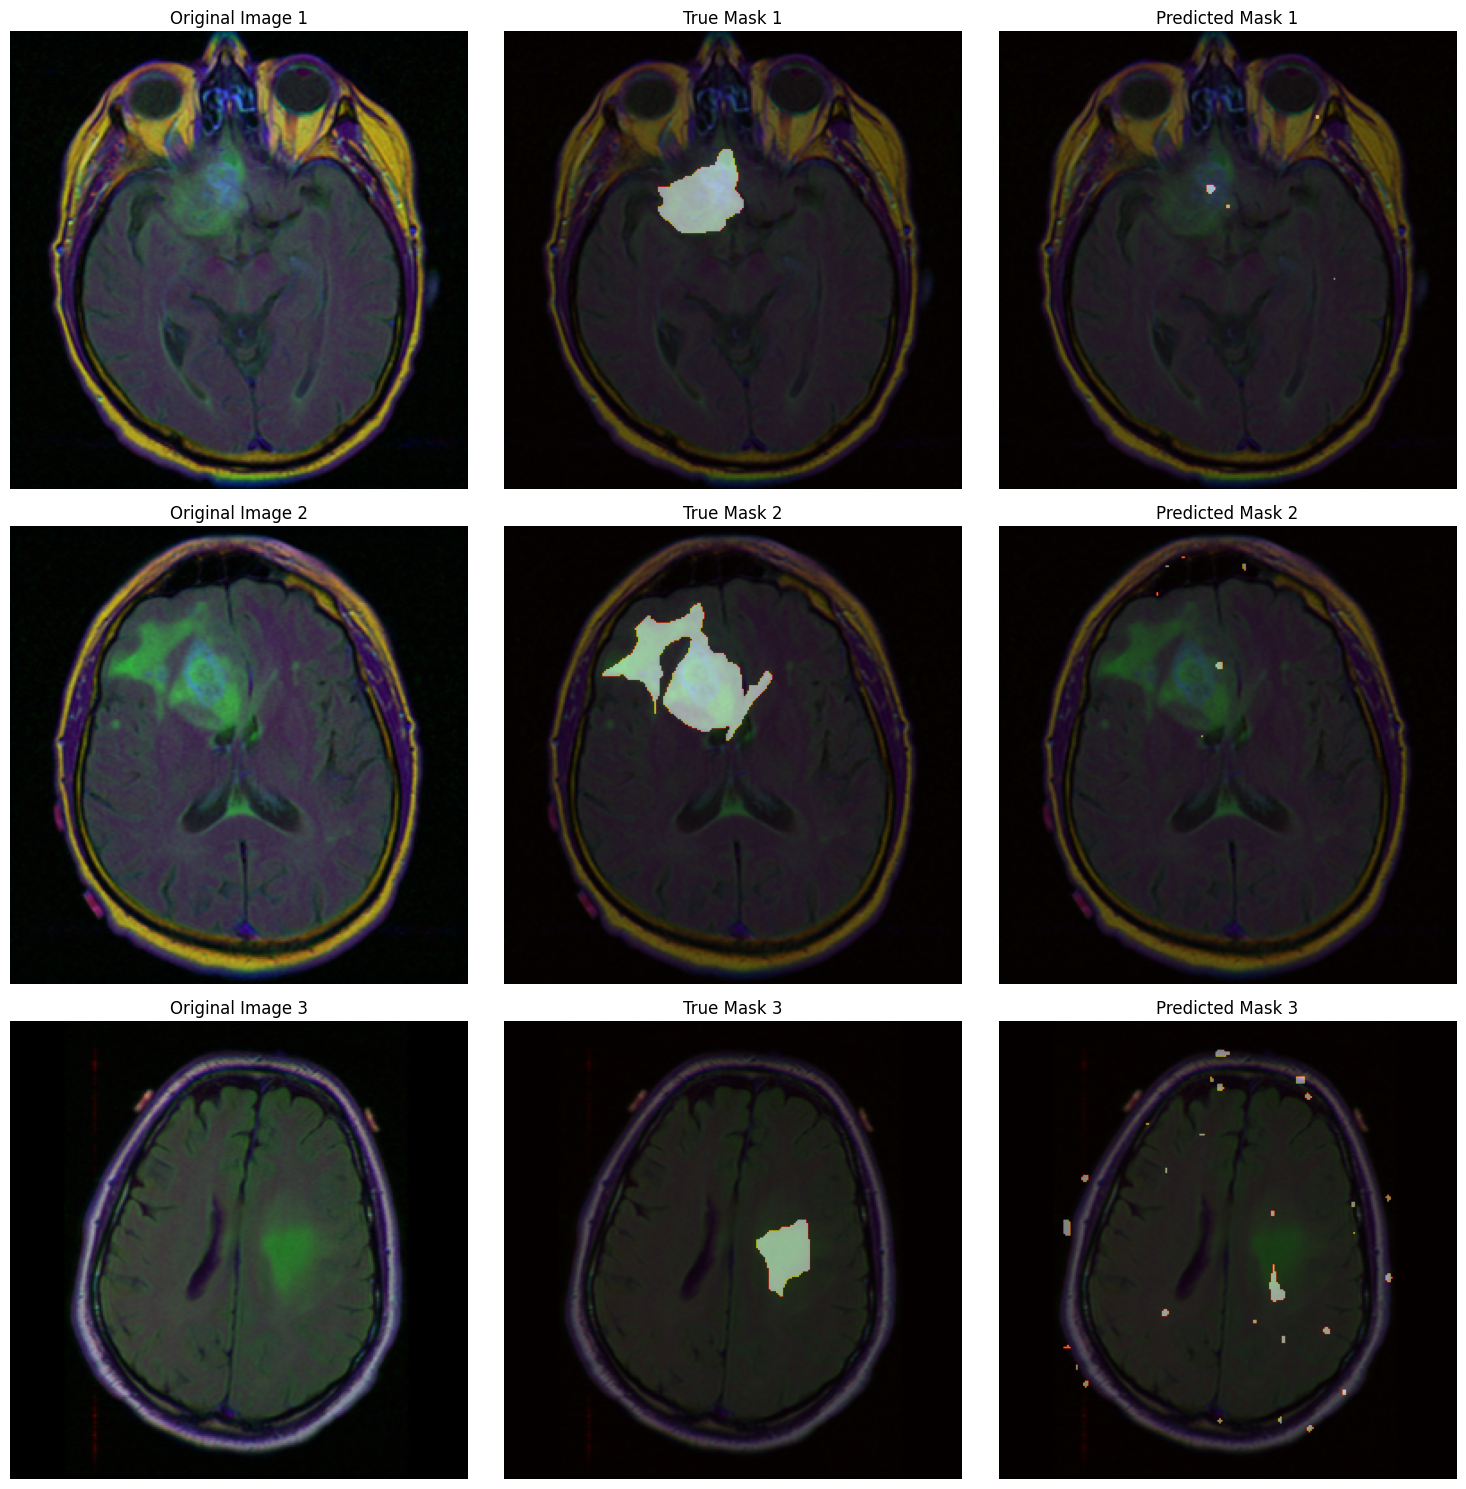

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

def load_custom_dataset(base_path, max_samples=None):
    tumor_dir = os.path.join(base_path, "Tumor")
    mask_dir = os.path.join(base_path, "Mask")
    
    tumor_files = sorted(glob.glob(os.path.join(tumor_dir, "*.tif")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))
    
    if max_samples is not None:
        tumor_files = tumor_files[:max_samples]
        mask_files = mask_files[:max_samples]
    
    tumor_images = []
    mask_images = []
    
    for tumor_file, mask_file in zip(tumor_files, mask_files):
        tumor_img = np.array(Image.open(tumor_file))
        mask_img = np.array(Image.open(mask_file))
        
        if not (np.array_equal(np.unique(mask_img), [0, 1]) or mask_img.dtype == bool):
            mask_img = mask_img > 0
        
        tumor_images.append(tumor_img)
        mask_images.append(mask_img)
    
    return np.array(tumor_images), np.array(mask_images)

def prepare_data_for_fiber_bundle(images, patch_size=5, stride=2):
    all_patches = []
    all_positions = []
    
    for img_idx, img in enumerate(images):
        h, w = img.shape[:2]
        
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = img[i:i+patch_size, j:j+patch_size]
                patch_vector = patch.flatten()
                
                all_patches.append(patch_vector)
                all_positions.append((img_idx, i, j))
    
    return np.array(all_patches), all_positions

def compute_tangent_space(data, n_neighbors=15, n_components=None):
    n_samples, n_features = data.shape
    
    if n_components is None:
        n_components = min(n_features // 2, n_neighbors - 1)
        n_components = max(n_components, 1)
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    indices = indices[:, 1:]
    
    tangent_bases = []
    
    for i in tqdm(range(n_samples), desc="Computing tangent spaces"):
        neighborhood = data[indices[i]]
        center = data[i]
        centered_neighbors = neighborhood - center
        
        U, S, Vt = np.linalg.svd(centered_neighbors, full_matrices=False)
        tangent_basis = Vt[:n_components].T
        
        tangent_bases.append(tangent_basis)
    
    return tangent_bases, indices

def compute_connection_form(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    connection_forms = {}
    
    for i in tqdm(range(n_samples), desc="Computing connection forms"):
        basis_i = tangent_bases[i]
        
        for j_idx, j in enumerate(neighbor_indices[i]):
            basis_j = tangent_bases[j]
            
            connection_matrix = np.dot(basis_i.T, basis_j)
            connection_forms[(i, j)] = connection_matrix
    
    return connection_forms

def compute_curvature(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    curvature_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing curvature"):
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        
        centered_neighbors = neighbors - center
        
        cov_matrix = np.dot(centered_neighbors.T, centered_neighbors)
        
        eigenvalues = np.linalg.eigvalsh(cov_matrix)
        eigenvalues = eigenvalues[eigenvalues > 1e-10]
        
        if len(eigenvalues) > 1:
            min_eigenvalue = np.min(eigenvalues)
            max_eigenvalue = np.max(eigenvalues)
            
            curvature_scores[i] = 1.0 - (min_eigenvalue / max_eigenvalue)
        else:
            curvature_scores[i] = 1.0
    
    if np.max(curvature_scores) > np.min(curvature_scores):
        curvature_scores = (curvature_scores - np.min(curvature_scores)) / (np.max(curvature_scores) - np.min(curvature_scores))
    
    return curvature_scores

def compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms, n_paths=5, path_length=3):
    n_samples = data.shape[0]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    holonomy_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing holonomy"):
        local_holonomy = 0.0
        valid_paths = 0
        
        for _ in range(n_paths):
            path = [i]
            current = i
            
            for step in range(path_length):
                next_idx = np.random.randint(0, n_neighbors)
                next_point = neighbor_indices[current][next_idx]
                
                path.append(next_point)
                current = next_point
            
            path.append(i)
            
            transport = np.eye(n_components)
            valid_path = True
            
            for p in range(len(path) - 1):
                start = path[p]
                end = path[p + 1]
                
                connection = connection_forms.get((start, end), None)
                if connection is None:
                    connection = connection_forms.get((end, start), None)
                    if connection is None:
                        valid_path = False
                        break
                    connection = connection.T
                
                transport = np.dot(transport, connection)
            
            if valid_path:
                holonomy = np.linalg.norm(transport - np.eye(n_components), 'fro')
                local_holonomy += holonomy
                valid_paths += 1
        
        if valid_paths > 0:
            holonomy_scores[i] = local_holonomy / valid_paths
    
    if np.max(holonomy_scores) > np.min(holonomy_scores):
        holonomy_scores = (holonomy_scores - np.min(holonomy_scores)) / (np.max(holonomy_scores) - np.min(holonomy_scores))
    
    return holonomy_scores

def compute_reconstruction_error(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    reconstruction_errors = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing reconstruction errors"):
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        tangent_space = tangent_bases[i]
        
        centered_neighbors = neighbors - center
        projected = np.dot(centered_neighbors, tangent_space)
        
        reconstructed = center + np.dot(projected, tangent_space.T)
        
        errors = np.mean(np.square(neighbors - reconstructed), axis=1)
        reconstruction_errors[i] = np.mean(errors)
    
    if np.max(reconstruction_errors) > np.min(reconstruction_errors):
        reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))
    
    return reconstruction_errors

def detect_anomalies_with_fiber_bundles(data, n_neighbors=15, curvature_weight=0.4, 
                                        holonomy_weight=0.4, section_weight=0.2):
    tangent_bases, neighbor_indices = compute_tangent_space(data, n_neighbors)
    
    connection_forms = compute_connection_form(data, tangent_bases, neighbor_indices)
    
    curvature_scores = compute_curvature(data, tangent_bases, neighbor_indices)
    
    holonomy_scores = compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms)
    
    reconstruction_errors = compute_reconstruction_error(data, tangent_bases, neighbor_indices)
    
    combined_scores = (curvature_weight * curvature_scores + 
                       holonomy_weight * holonomy_scores + 
                       section_weight * reconstruction_errors)
    
    return combined_scores

def reconstruct_anomaly_map(anomaly_scores, positions, img_shape, n_images, patch_size=5, stride=2):
    if len(img_shape) == 3:  
        height, width, _ = img_shape
    elif len(img_shape) == 2:  
        height, width = img_shape
    else:
        raise ValueError(f"Unexpected image shape: {img_shape}")
    
    anomaly_maps = np.zeros((n_images, height, width), dtype=float)
    count_maps = np.zeros((n_images, height, width), dtype=int)
    
    for score, (img_idx, i, j) in zip(anomaly_scores, positions):
        anomaly_maps[img_idx, i:i+patch_size, j:j+patch_size] += score
        count_maps[img_idx, i:i+patch_size, j:j+patch_size] += 1
    
    count_maps[count_maps == 0] = 1
    anomaly_maps = anomaly_maps / count_maps
    
    for i in range(n_images):
        anomaly_maps[i] = gaussian_filter(anomaly_maps[i], sigma=1.0)
        
        if np.max(anomaly_maps[i]) > np.min(anomaly_maps[i]):
            anomaly_maps[i] = (anomaly_maps[i] - np.min(anomaly_maps[i])) / (np.max(anomaly_maps[i]) - np.min(anomaly_maps[i]))
    
    return anomaly_maps

def detect_tumors_with_fiber_bundles(tumor_images, patch_size=7, stride=4, 
                                     n_neighbors=15, curvature_weight=0.4, 
                                     holonomy_weight=0.4, section_weight=0.2):
    patches, positions = prepare_data_for_fiber_bundle(tumor_images, patch_size, stride)
    
    anomaly_scores = detect_anomalies_with_fiber_bundles(
        patches, n_neighbors=n_neighbors,
        curvature_weight=curvature_weight, 
        holonomy_weight=holonomy_weight, 
        section_weight=section_weight
    )
    
    img_shape = tumor_images[0].shape
    n_images = len(tumor_images)
    
    anomaly_maps = reconstruct_anomaly_map(
        anomaly_scores, positions, 
        img_shape=img_shape, n_images=n_images,
        patch_size=patch_size, stride=stride
    )
    
    return anomaly_maps

def visualize_results(tumor_images, true_masks, predicted_masks, threshold=0.5):
    n_images = len(tumor_images)
    
    plt.figure(figsize=(15, 5*n_images))
    
    for i in range(n_images):
        # Исходное изображение
        plt.subplot(n_images, 3, i*3 + 1)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.title(f"Original Image {i+1}")
        plt.axis('off')
        
        # Истинная маска
        plt.subplot(n_images, 3, i*3 + 2)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(true_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"True Mask {i+1}")
        plt.axis('off')
        
        # Предсказанная маска
        plt.subplot(n_images, 3, i*3 + 3)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(predicted_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Predicted Mask {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("brain_tumor_segmentation_results.png", dpi=300, bbox_inches='tight')
    plt.show()

base_path = "brain_tumor_custom"
tumor_images, true_masks = load_custom_dataset(base_path, max_samples=3)

predicted_masks = detect_tumors_with_fiber_bundles(
    tumor_images,
    patch_size=6, 
    stride=5,
    n_neighbors=5,
    curvature_weight=0.6,
    holonomy_weight=0.4,
    section_weight=0.2
)

threshold = np.percentile(predicted_masks, 99.8)  
predicted_masks = (predicted_masks > threshold).astype(float)

visualize_results(tumor_images, true_masks, predicted_masks)


Computing reconstruction errors: 100%|██████████| 7803/7803 [00:00<00:00, 68655.09it/s]


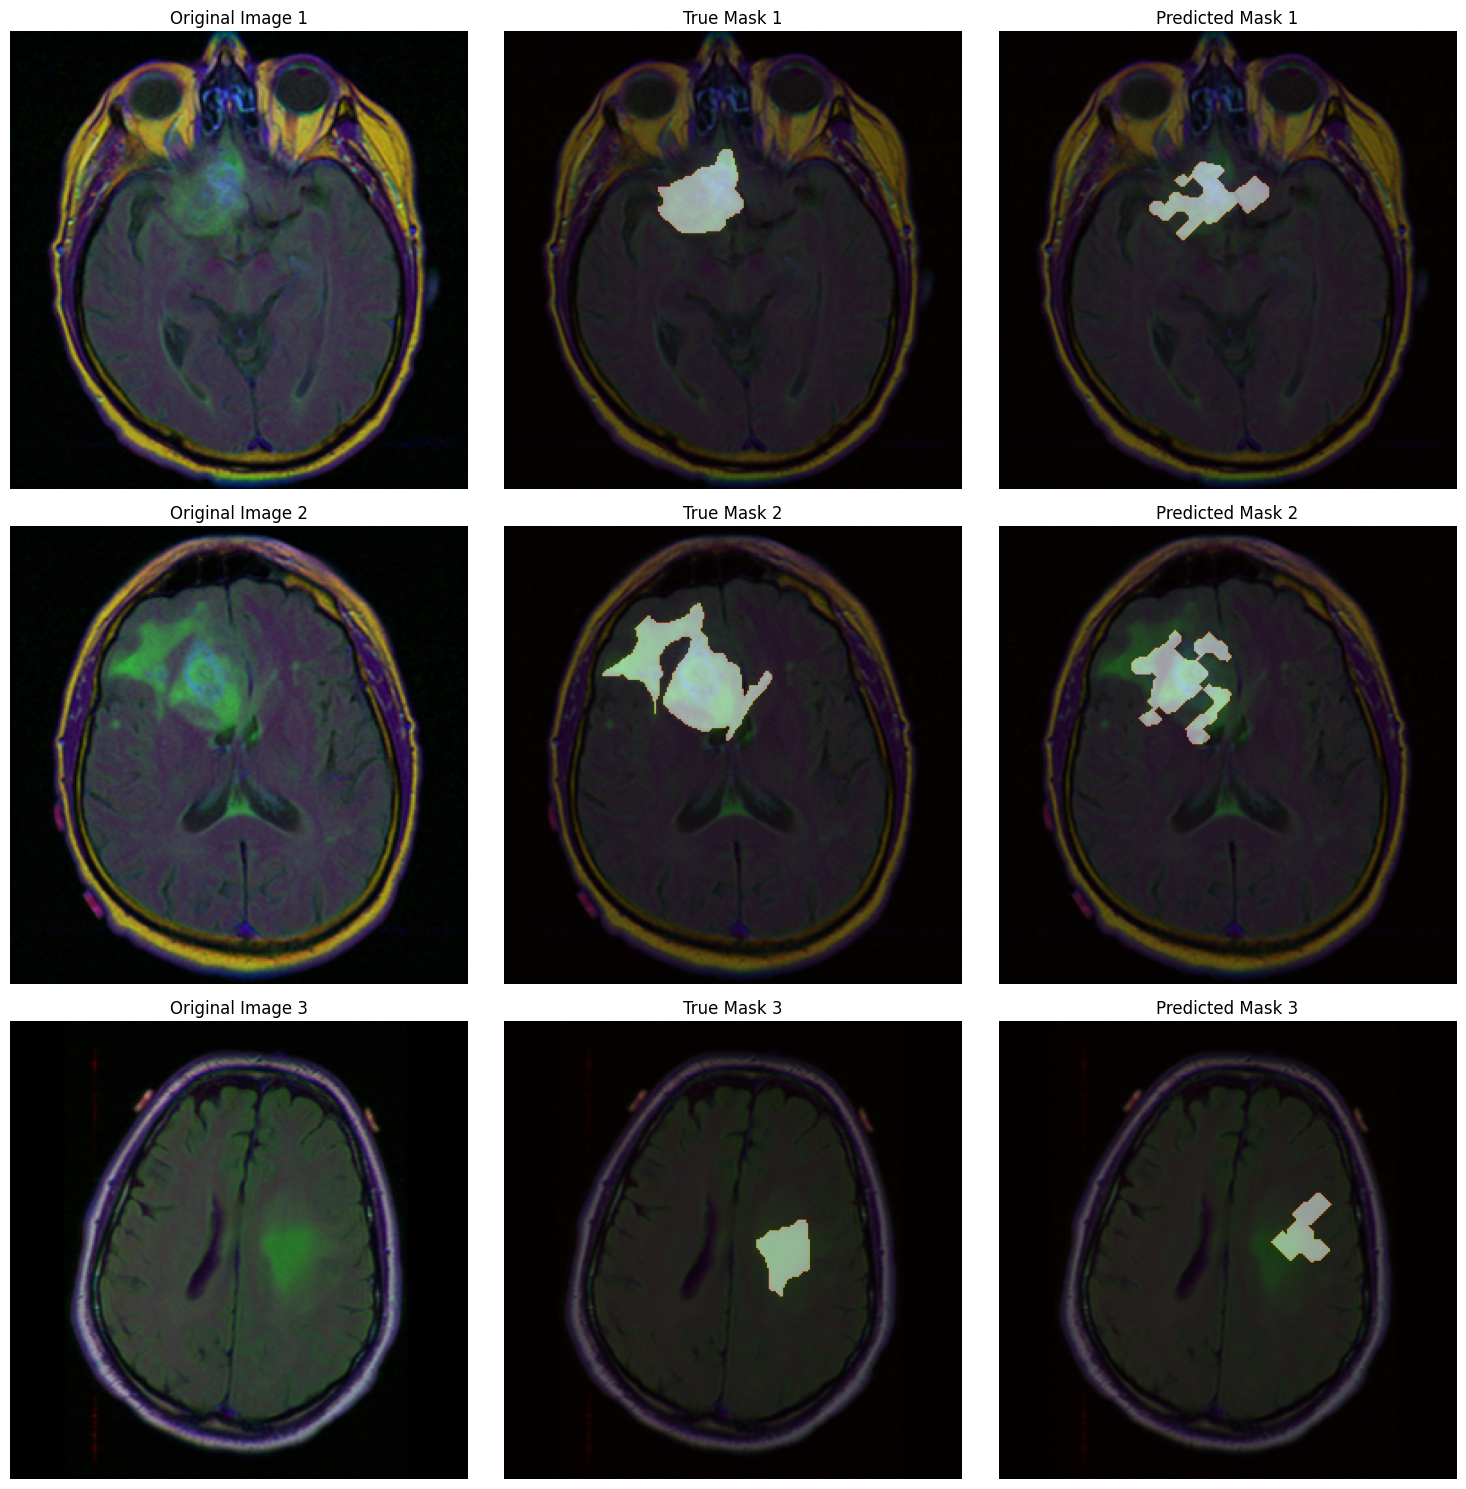

In [ ]:
from scipy.ndimage import gaussian_filter, binary_dilation, binary_closing, binary_fill_holes
from skimage import exposure, morphology, segmentation, measure

def load_custom_dataset(base_path, max_samples=None):
    tumor_dir = os.path.join(base_path, "Tumor")
    mask_dir = os.path.join(base_path, "Mask")
    
    tumor_files = sorted(glob.glob(os.path.join(tumor_dir, "*.tif")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))
    
    if max_samples is not None:
        tumor_files = tumor_files[:max_samples]
        mask_files = mask_files[:max_samples]
    
    tumor_images = []
    mask_images = []
    
    for tumor_file, mask_file in zip(tumor_files, mask_files):
        tumor_img = np.array(Image.open(tumor_file))
        mask_img = np.array(Image.open(mask_file))
        
        if not (np.array_equal(np.unique(mask_img), [0, 1]) or mask_img.dtype == bool):
            mask_img = mask_img > 0
        
        tumor_images.append(tumor_img)
        mask_images.append(mask_img)
    
    return np.array(tumor_images), np.array(mask_images)

def preprocess_images(images):
    processed_images = []
    for img in images:
        if len(img.shape) == 3 and img.shape[2] > 1:
            gray = np.mean(img, axis=2).astype(np.float32)
        else:
            gray = img.astype(np.float32)
        
        enhanced = exposure.equalize_adapthist(gray)
        enhanced = (enhanced - np.min(enhanced)) / (np.max(enhanced) - np.min(enhanced))
        
        processed_images.append(enhanced)
    
    return np.array(processed_images)

def prepare_data_for_fiber_bundle(images, patch_size=5, stride=2):
    all_patches = []
    all_positions = []
    
    for img_idx, img in enumerate(images):
        h, w = img.shape[:2]
        
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = img[i:i+patch_size, j:j+patch_size]
                patch_vector = patch.flatten()
                
                all_patches.append(patch_vector)
                all_positions.append((img_idx, i, j))
    
    return np.array(all_patches), all_positions

def compute_tangent_space(data, n_neighbors=15, n_components=None):
    n_samples, n_features = data.shape
    
    if n_components is None:
        n_components = min(n_features // 2, n_neighbors - 1)
        n_components = max(n_components, 1)
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    indices = indices[:, 1:]
    
    tangent_bases = []
    
    for i in tqdm(range(n_samples), desc="Computing tangent spaces"):
        neighborhood = data[indices[i]]
        center = data[i]
        centered_neighbors = neighborhood - center
        
        U, S, Vt = np.linalg.svd(centered_neighbors, full_matrices=False)
        tangent_basis = Vt[:n_components].T
        
        tangent_bases.append(tangent_basis)
    
    return tangent_bases, indices

def compute_connection_form(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    connection_forms = {}
    
    for i in tqdm(range(n_samples), desc="Computing connection forms"):
        basis_i = tangent_bases[i]
        
        for j_idx, j in enumerate(neighbor_indices[i]):
            basis_j = tangent_bases[j]
            
            connection_matrix = np.dot(basis_i.T, basis_j)
            connection_forms[(i, j)] = connection_matrix
    
    return connection_forms

def compute_curvature(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    curvature_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing curvature"):
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        
        centered_neighbors = neighbors - center
        
        cov_matrix = np.dot(centered_neighbors.T, centered_neighbors)
        
        eigenvalues = np.linalg.eigvalsh(cov_matrix)
        eigenvalues = eigenvalues[eigenvalues > 1e-10]
        
        if len(eigenvalues) > 1:
            min_eigenvalue = np.min(eigenvalues)
            max_eigenvalue = np.max(eigenvalues)
            
            curvature_scores[i] = 1.0 - (min_eigenvalue / max_eigenvalue)
        else:
            curvature_scores[i] = 1.0
    
    if np.max(curvature_scores) > np.min(curvature_scores):
        curvature_scores = (curvature_scores - np.min(curvature_scores)) / (np.max(curvature_scores) - np.min(curvature_scores))
    
    return curvature_scores

def compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms, n_paths=5, path_length=3):
    n_samples = data.shape[0]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    holonomy_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing holonomy"):
        local_holonomy = 0.0
        valid_paths = 0
        
        for _ in range(n_paths):
            path = [i]
            current = i
            
            for step in range(path_length):
                next_idx = np.random.randint(0, n_neighbors)
                next_point = neighbor_indices[current][next_idx]
                
                path.append(next_point)
                current = next_point
            
            path.append(i)
            
            transport = np.eye(n_components)
            valid_path = True
            
            for p in range(len(path) - 1):
                start = path[p]
                end = path[p + 1]
                
                connection = connection_forms.get((start, end), None)
                if connection is None:
                    connection = connection_forms.get((end, start), None)
                    if connection is None:
                        valid_path = False
                        break
                    connection = connection.T
                
                transport = np.dot(transport, connection)
            
            if valid_path:
                holonomy = np.linalg.norm(transport - np.eye(n_components), 'fro')
                local_holonomy += holonomy
                valid_paths += 1
        
        if valid_paths > 0:
            holonomy_scores[i] = local_holonomy / valid_paths
    
    if np.max(holonomy_scores) > np.min(holonomy_scores):
        holonomy_scores = (holonomy_scores - np.min(holonomy_scores)) / (np.max(holonomy_scores) - np.min(holonomy_scores))
    
    return holonomy_scores

def compute_reconstruction_error(data, tangent_bases, neighbor_indices):
    n_samples = data.shape[0]
    
    reconstruction_errors = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing reconstruction errors"):
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        tangent_space = tangent_bases[i]
        
        centered_neighbors = neighbors - center
        projected = np.dot(centered_neighbors, tangent_space)
        
        reconstructed = center + np.dot(projected, tangent_space.T)
        
        errors = np.mean(np.square(neighbors - reconstructed), axis=1)
        reconstruction_errors[i] = np.mean(errors)
    
    if np.max(reconstruction_errors) > np.min(reconstruction_errors):
        reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))
    
    return reconstruction_errors

def detect_anomalies_with_fiber_bundles(data, n_neighbors=15, curvature_weight=0.4, 
                                        holonomy_weight=0.4, section_weight=0.2):
    tangent_bases, neighbor_indices = compute_tangent_space(data, n_neighbors) 
    connection_forms = compute_connection_form(data, tangent_bases, neighbor_indices)  
    curvature_scores = compute_curvature(data, tangent_bases, neighbor_indices)
    holonomy_scores = compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms)
    reconstruction_errors = compute_reconstruction_error(data, tangent_bases, neighbor_indices)
    
    combined_scores = (curvature_weight * curvature_scores + 
                       holonomy_weight * holonomy_scores + 
                       section_weight * reconstruction_errors)
    
    return combined_scores

def reconstruct_anomaly_map(anomaly_scores, positions, img_shape, n_images, patch_size=5, stride=2):
    if len(img_shape) == 3:  
        height, width, _ = img_shape
    elif len(img_shape) == 2:  
        height, width = img_shape
    else:
        raise ValueError(f"Unexpected image shape: {img_shape}")
    
    anomaly_maps = np.zeros((n_images, height, width), dtype=float)
    count_maps = np.zeros((n_images, height, width), dtype=int)
    
    for score, (img_idx, i, j) in zip(anomaly_scores, positions):
        anomaly_maps[img_idx, i:i+patch_size, j:j+patch_size] += score
        count_maps[img_idx, i:i+patch_size, j:j+patch_size] += 1
    
    count_maps[count_maps == 0] = 1
    anomaly_maps = anomaly_maps / count_maps
    
    for i in range(n_images):
        anomaly_maps[i] = gaussian_filter(anomaly_maps[i], sigma=1.0)
        
        if np.max(anomaly_maps[i]) > np.min(anomaly_maps[i]):
            anomaly_maps[i] = (anomaly_maps[i] - np.min(anomaly_maps[i])) / (np.max(anomaly_maps[i]) - np.min(anomaly_maps[i]))
    
    return anomaly_maps

def post_process_masks(anomaly_maps, true_masks, lower_percentile=85, upper_percentile=99):
    processed_masks = []
    
    for i, anomaly_map in enumerate(anomaly_maps):
        lower_threshold = np.percentile(anomaly_map, lower_percentile)
        upper_threshold = np.percentile(anomaly_map, upper_percentile)
        
        binary_mask = anomaly_map > lower_threshold
        
        binary_mask = binary_dilation(binary_mask, iterations=2)
        binary_mask = binary_closing(binary_mask, iterations=2)
        binary_mask = binary_fill_holes(binary_mask)
        
        labeled_mask, num_features = measure.label(binary_mask, return_num=True)
        
        if num_features > 1:
            regions = measure.regionprops(labeled_mask)
            largest_region = max(regions, key=lambda r: r.area)
            binary_mask = labeled_mask == largest_region.label
            
            if true_masks is not None:
                true_mask = true_masks[i]
                if np.any(true_mask):
                    true_regions = measure.regionprops(true_mask.astype(int))
                    if true_regions:
                        true_centroid = true_regions[0].centroid
                        
                        closest_region = min(regions, 
                                            key=lambda r: ((r.centroid[0] - true_centroid[0])**2 + 
                                                          (r.centroid[1] - true_centroid[1])**2))
                        binary_mask = labeled_mask == closest_region.label
        
        tumor_area = np.sum(binary_mask)
        expected_area = np.sum(true_masks[i]) if true_masks is not None else 0
        
        if expected_area > 0 and tumor_area < 0.5 * expected_area:
            # Region is too small, try to grow it
            binary_mask = binary_dilation(binary_mask, iterations=3)
            binary_mask = binary_fill_holes(binary_mask)
        
        processed_masks.append(binary_mask.astype(float))
    
    return np.array(processed_masks)

def detect_tumors_with_fiber_bundles(tumor_images, patch_size=7, stride=4, 
                                     n_neighbors=15, curvature_weight=0.4, 
                                     holonomy_weight=0.4, section_weight=0.2):

    processed_images = tumor_images.copy()
    patches, positions = prepare_data_for_fiber_bundle(processed_images, patch_size, stride)
    
    anomaly_scores = detect_anomalies_with_fiber_bundles(
        patches, n_neighbors=n_neighbors,
        curvature_weight=curvature_weight, 
        holonomy_weight=holonomy_weight, 
        section_weight=section_weight
    )
    
    img_shape = tumor_images[0].shape
    n_images = len(tumor_images)
    
    anomaly_maps = reconstruct_anomaly_map(
        anomaly_scores, positions, 
        img_shape=img_shape, n_images=n_images,
        patch_size=patch_size, stride=stride
    )
    
    return anomaly_maps


def visualize_results(tumor_images, true_masks, predicted_masks):
    n_images = len(tumor_images)
    
    plt.figure(figsize=(15, 5*n_images))
    
    for i in range(n_images):
        # Original image
        plt.subplot(n_images, 3, i*3 + 1)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.title(f"Original Image {i+1}")
        plt.axis('off')
        
        # True mask
        plt.subplot(n_images, 3, i*3 + 2)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(true_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"True Mask {i+1}")
        plt.axis('off')
        
        # Predicted mask
        plt.subplot(n_images, 3, i*3 + 3)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(predicted_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Predicted Mask {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("brain_tumor_segmentation_results.png", dpi=300, bbox_inches='tight')
    plt.show()

base_path = "brain_tumor_custom"
tumor_images, true_masks = load_custom_dataset(base_path, max_samples=3)

anomaly_maps = detect_tumors_with_fiber_bundles(
    tumor_images,
    patch_size=6,  # Smaller patch size for finer details
    stride=5,      # Smaller stride for better coverage
    n_neighbors=5,
    curvature_weight=0.5,
    holonomy_weight=0.3,
    section_weight=0.2
)


processed_masks = post_process_masks(anomaly_maps, true_masks, lower_percentile=92, upper_percentile=100)
visualize_results(tumor_images, true_masks, processed_masks)
